# Seoul Real Estate Investment Analysis by Investor Profile (2018–2024)

## Objective
Recommend the optimal district (gu) and building type combination in Seoul for three investor profiles:
**Conservative**, **Balanced**, and **Aggressive** — using a data-driven scoring framework.

## Analysis Framework
| Metric | Meaning | Preferred Direction |
|--------|---------|---------------------|
| Growth | Average annual price-per-pyeong growth rate | Higher is better ↑ |
| Price | Current price-per-pyeong vs Seoul average | Lower = undervalued ↓ |
| Volatility | Standard deviation of growth rates | Lower = more stable ↓ |

→ All 3 metrics are **Z-score normalized**, then combined using investor-profile weights.

## Preprocessing Policy — Dual Approach
This notebook **removes price outliers (IQR method)**.
> For fair Z-score comparison across districts, extreme values must be removed.
> Outliers skew Z-scores and distort the final ranking.
>
> ※ For overall market trend analysis (raw data preserved), see the companion notebook
>    `Seoul_Real_Estate_Market_Overview.ipynb`.

## Weight Design
| Investor Profile | Growth | Price | Volatility | Total |
|-----------------|--------|-------|------------|-------|
| Conservative | 0.5 | 1.0 | **1.5** | 3.0 |
| Balanced | 1.0 | 1.0 | 1.0 | 3.0 |
| Aggressive | **1.5** | 1.0 | 0.5 | 3.0 |

※ All profiles sum to 3.0 → scores are on the same scale (fair comparison).


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Font settings for Korean district/building type labels in plots
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [21]:
# Load Data
# Uses relative paths → place CSV files in the data/ folder
data_2018 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2018.csv', encoding="euc-kr",low_memory = False)
data_2019 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2019.csv', encoding="euc-kr",low_memory = False)
data_2020 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2020.csv', encoding="euc-kr",low_memory = False)
data_2021 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2021.csv', encoding="euc-kr",low_memory = False)
data_2022 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2022.csv', encoding="euc-kr",low_memory = False) 
data_2023 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2023.csv', encoding="euc-kr",low_memory = False)
data_2024 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2024.csv', encoding="euc-kr",low_memory = False)

In [22]:
# Merge All Years
dfs = [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
df_all = pd.concat(dfs, axis=0, ignore_index=True, join="inner")
print("Combined dataset shape:", df_all.shape)

Combined dataset shape: (833614, 21)


In [23]:
# Rename Columns to English 
col_map = {
    "물건금액(만원)": "price_10k_krw",
    "건물면적(㎡)":   "area_sqm",
    "자치구명":       "district",
    "건물용도":       "building_type",
    "접수연도":       "year",
    "건축년도":       "year_built",
    "취소일":         "cancellation_date",
    "계약일":         "contract_date",
}
df_all.rename(columns={k: v for k, v in col_map.items() if k in df_all.columns}, inplace=True)
print("Columns after renaming:")
print(df_all.columns.tolist())

Columns after renaming:
['year', '자치구코드', 'district', '법정동코드', '법정동명', '지번구분', '지번구분명', '본번', '부번', '건물명', 'contract_date', 'price_10k_krw', 'area_sqm', '토지면적(㎡)', '층', '권리구분', 'cancellation_date', 'year_built', 'building_type', '신고구분', '신고한 개업공인중개사 시군구명']


In [24]:
# ── Remove Cancelled Transactions ────────────────────────────────────
df_all = df_all[df_all["cancellation_date"].isna()]
print("After removing cancellations:", df_all.shape)

After removing cancellations: (808073, 21)


## EDA — Before IQR Outlier Removal

In [25]:
# EDA: Pre-removal Statistics
before_count = len(df_all)
before_mean  = df_all["price_10k_krw"].mean()
before_std   = df_all["price_10k_krw"].std()

print(f"[Before removal] Rows: {before_count:,} | "
      f"Mean: {before_mean:,.0f} × 10k KRW | Std: {before_std:,.0f} × 10k KRW")
print()

# Missing value rates
null_rate = (df_all.isnull().sum() / len(df_all) * 100).round(2)
null_df = null_rate[null_rate > 0].sort_values(ascending=False)
print("Missing value rates (columns with gaps only):")
print(null_df.to_string())

[Before removal] Rows: 808,073 | Mean: 63,835 × 10k KRW | Std: 71,754 × 10k KRW

Missing value rates (columns with gaps only):
cancellation_date    100.00
권리구분                  99.09
신고한 개업공인중개사 시군구명      78.43
신고구분                  73.55
토지면적(㎡)               20.00
지번구분                   6.73
지번구분명                  6.73
본번                     6.73
부번                     6.73
건물명                    6.72
층                      6.72
year_built             0.41


## Preprocessing

In [26]:
# IQR-Based Outlier Removal
# [Decision Rationale] Why remove outliers here but not in the market overview?
# For Z-score comparison across 25 districts, a single extreme-price transaction
# in one district can dominate the Z-score and distort the ranking.
# IQR method: values outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR] are flagged as outliers.

Q1 = df_all["price_10k_krw"].quantile(0.25)
Q3 = df_all["price_10k_krw"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_before = df_all.copy()  # keep pre-removal copy for comparison
df_all = df_all[
    (df_all["price_10k_krw"] >= lower) &
    (df_all["price_10k_krw"] <= upper)
]
print("After IQR outlier removal:", df_all.shape)
print(f"  Lower bound: {lower:,.0f} × 10k KRW")
print(f"  Upper bound: {upper:,.0f} × 10k KRW")
print(f"  Removed: {len(df_before) - len(df_all):,} rows "
      f"({(len(df_before) - len(df_all)) / len(df_before) * 100:.1f}%)")

After IQR outlier removal: (757070, 21)
  Lower bound: -58,600 × 10k KRW
  Upper bound: 163,000 × 10k KRW
  Removed: 51,003 rows (6.3%)


## EDA — Before vs After IQR Removal

Before: 808,073 rows
After:  757,070 rows
Removed: 51,003 rows (6.3%)
Mean shift: 63,835 → 50,868 × 10k KRW


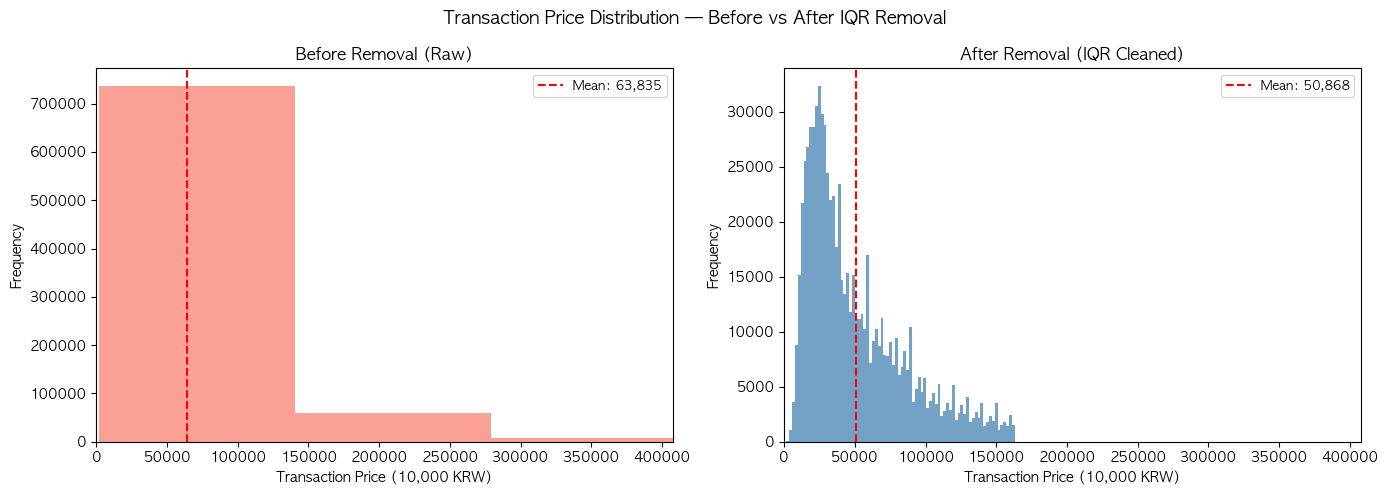

In [27]:
# EDA: Distribution Comparison (Before vs After)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Price Distribution — Before vs After IQR Removal",
             fontsize=13, fontweight="bold")

for ax, df_plot, title, color in [
    (axes[0], df_before, "Before Removal (Raw)", "salmon"),
    (axes[1], df_all,   "After Removal (IQR Cleaned)", "steelblue"),
]:
    ax.hist(df_plot["price_10k_krw"].dropna(), bins=80,
            color=color, alpha=0.75, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("Transaction Price (10,000 KRW)")
    ax.set_ylabel("Frequency")
    mean_val = df_plot["price_10k_krw"].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"Mean: {mean_val:,.0f}")
    ax.legend(fontsize=9)
    ax.set_xlim(0, df_before["price_10k_krw"].quantile(0.995))

before_n, after_n = len(df_before), len(df_all)
removed = before_n - after_n
print(f"Before: {before_n:,} rows")
print(f"After:  {after_n:,} rows")
print(f"Removed: {removed:,} rows ({removed / before_n * 100:.1f}%)")
print(f"Mean shift: {df_before['price_10k_krw'].mean():,.0f} → "
      f"{df_all['price_10k_krw'].mean():,.0f} × 10k KRW")

plt.tight_layout()
plt.show()

In [28]:
# Clean Year Built
df_all = df_all.copy()
df_all["year_built"] = pd.to_numeric(df_all["year_built"], errors="coerce")
current_year = pd.Timestamp.today().year
df_all = df_all[(df_all["year_built"] >= 1900) & (df_all["year_built"] <= current_year)]
print("After cleaning year_built:", df_all.shape)

After cleaning year_built: (747374, 21)


In [29]:
# Derive Key Features 
df_all["area_sqm"] = pd.to_numeric(df_all["area_sqm"], errors="coerce")
df_all["area_pyeong"]      = df_all["area_sqm"] / 3.3
df_all["price_per_pyeong"] = df_all["price_10k_krw"] / df_all["area_pyeong"]

# Annual average price per pyeong
avg_py_year = df_all.groupby("year")["price_per_pyeong"].mean().reset_index().round(1)
print(avg_py_year)

# Building type categories (verify they match the 4 types in the PPT)
print("\nBuilding type categories:")
print(df_all["building_type"].value_counts())

   year  price_per_pyeong
0  2018            2271.4
1  2019            2587.3
2  2020            2742.6
3  2021            2936.6
4  2022            2891.1
5  2023            3317.8
6  2024            3552.5

Building type categories:
building_type
아파트      340152
연립다세대    281033
오피스텔      83000
단독다가구     43189
Name: count, dtype: int64


In [30]:
# Parse Contract Date
# Split contract_date into year and month for potential seasonality analysis
df_all = df_all.copy()
df_all["contract_date"]  = pd.to_datetime(df_all["contract_date"], errors="coerce", format="%Y%m%d")
df_all["contract_year"]  = df_all["contract_date"].dt.year
df_all["contract_month"] = df_all["contract_date"].dt.month

print("Contract date parsing result:")
print(df_all[["contract_date", "contract_year", "contract_month"]].head())
print(df_all.shape)

Contract date parsing result:
  contract_date  contract_year  contract_month
0    2019-04-25           2019               4
1    2019-03-16           2019               3
2    2019-02-21           2019               2
3    2019-01-21           2019               1
4    2019-01-03           2019               1
(747374, 25)


## District-Level Baseline Analysis

In [31]:
# Average Transaction Price by District
avg_price_district = (
    df_all.groupby("district")["price_10k_krw"]
    .mean().reset_index().round(2)
    .sort_values("price_10k_krw", ascending=False).reset_index(drop=True)
)
print(avg_price_district)

   district  price_10k_krw
0       성동구       82094.57
1       용산구       67570.54
2       서초구       66012.56
3       동작구       65041.10
4       강남구       65031.02
5       송파구       62824.51
6        중구       60605.07
7       마포구       59248.01
8       강동구       58900.20
9      영등포구       57168.08
10      광진구       55054.87
11     서대문구       54410.30
12     동대문구       51878.50
13      성북구       51810.46
14      양천구       50622.27
15      종로구       49838.52
16      노원구       46233.00
17      관악구       43161.51
18      중랑구       42120.80
19      구로구       40500.76
20      강서구       40094.48
21      은평구       38113.55
22      금천구       35549.38
23      도봉구       34773.83
24      강북구       33973.28


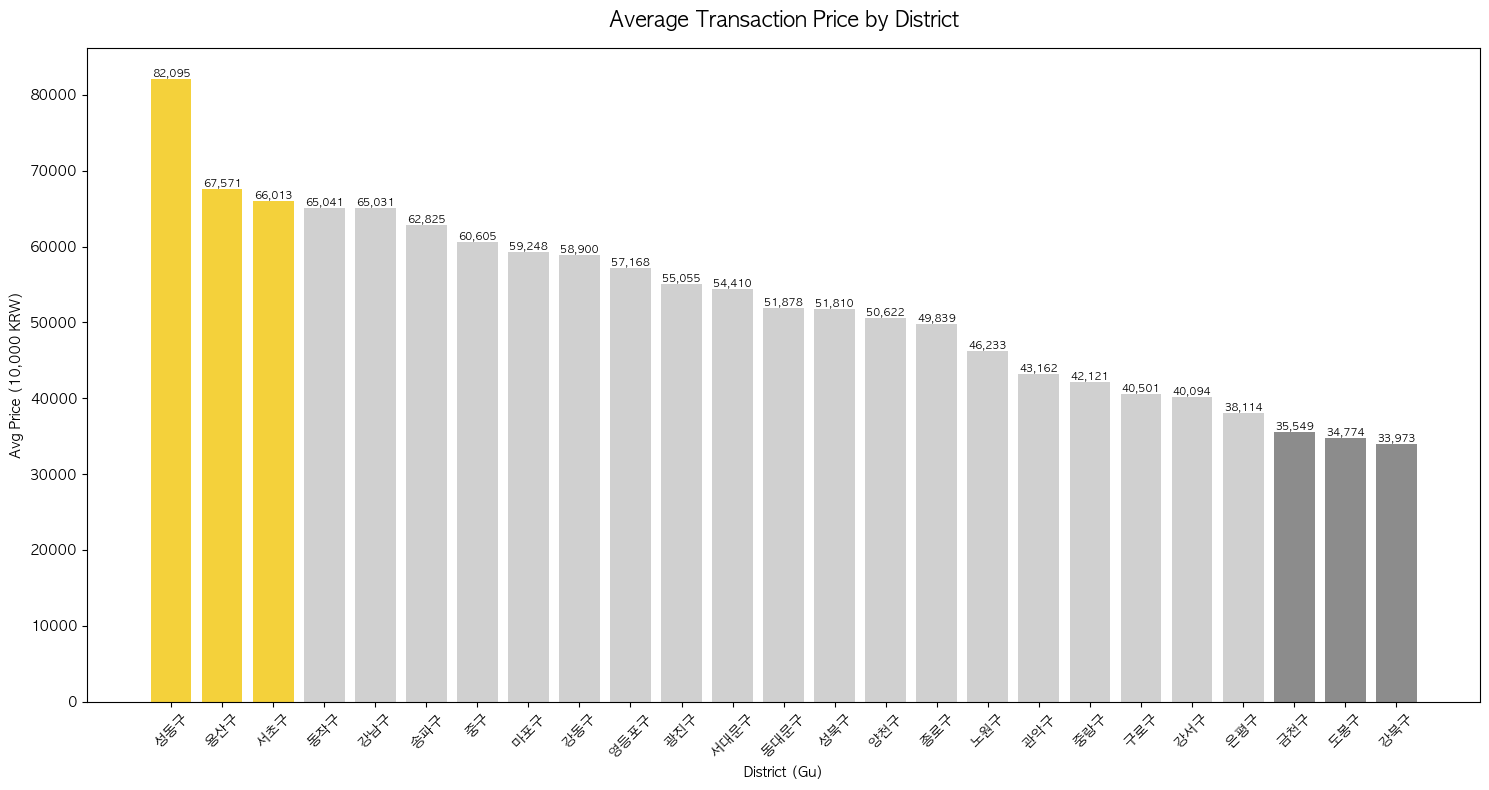

In [32]:
# Visualization: Avg Transaction Price by District
avg_sorted = avg_price_district.copy()

colors = []
for i in range(len(avg_sorted)):
    if i < 3:
        colors.append("#F4D13B")       # top 3 — highlighted
    elif i >= len(avg_sorted) - 3:
        colors.append("#8C8C8C")       # bottom 3 — gray
    else:
        colors.append("#D0D0D0")       # others — light gray

plt.figure(figsize=(15, 8))
plt.bar(avg_sorted["district"], avg_sorted["price_10k_krw"], color=colors)
plt.title("Average Transaction Price by District", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("District (Gu)")
plt.ylabel("Avg Price (10,000 KRW)")
plt.xticks(rotation=45)
for i, v in enumerate(avg_sorted["price_10k_krw"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()

In [33]:
# Average Price per Pyeong by District
avg_py_district = (
    df_all.groupby("district")["price_per_pyeong"]
    .mean().reset_index().round(2)
    .sort_values("price_per_pyeong", ascending=False).reset_index(drop=True)
)
print(avg_py_district)

   district  price_per_pyeong
0       강남구           4361.82
1       용산구           4089.75
2       성동구           4017.59
3       서초구           3858.76
4       송파구           3517.79
5       마포구           3415.35
6        중구           3312.33
7       동작구           3228.46
8      영등포구           3182.59
9       강동구           3132.77
10      광진구           2955.85
11     동대문구           2807.20
12     서대문구           2749.10
13      종로구           2739.47
14      양천구           2601.35
15      성북구           2502.73
16      노원구           2484.62
17      강서구           2424.37
18      관악구           2306.98
19      금천구           2205.51
20      중랑구           2197.89
21      은평구           2177.04
22      구로구           2173.11
23      도봉구           1832.33
24      강북구           1818.83


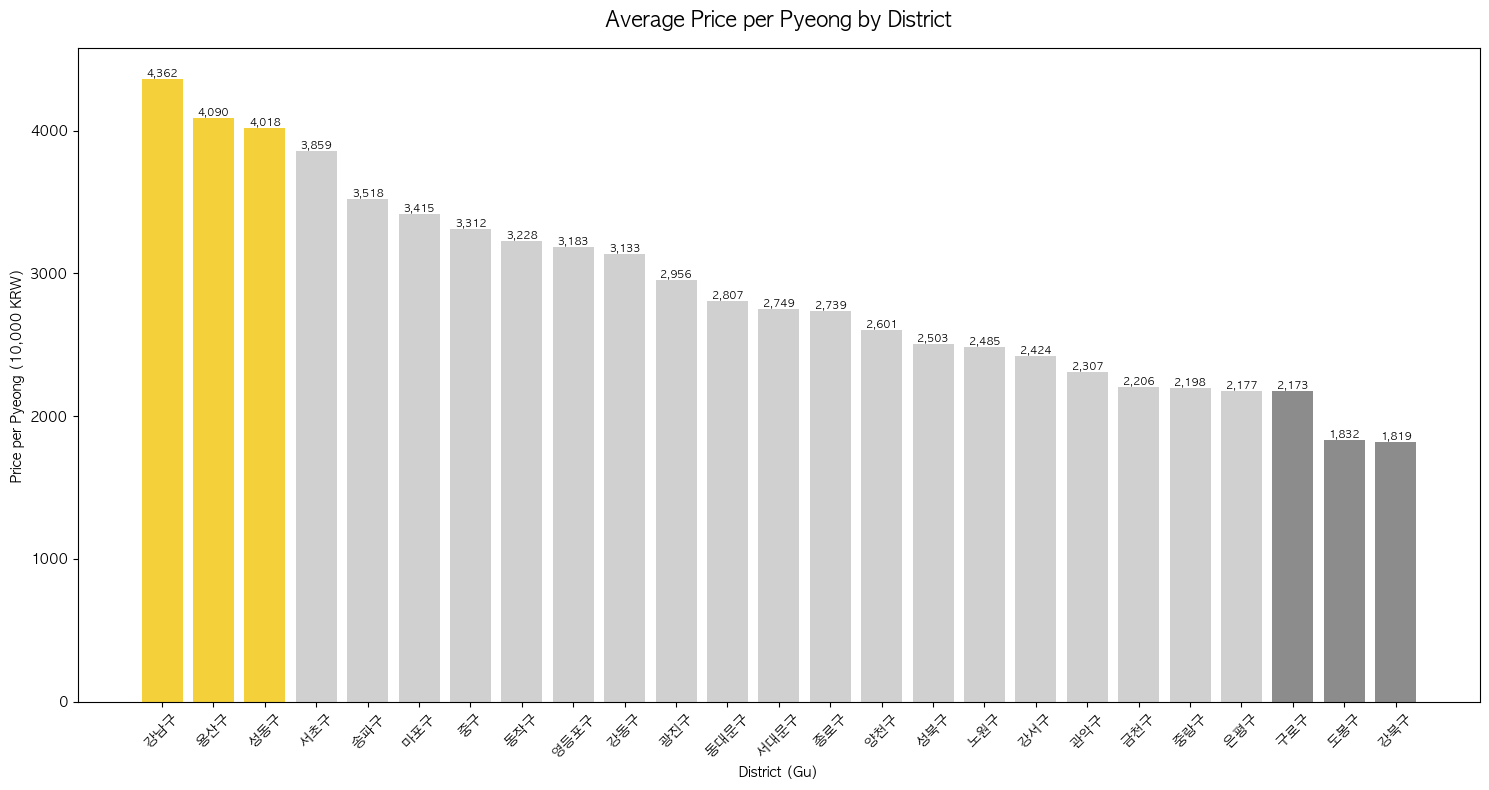

In [34]:
# Visualization: Avg Price per Pyeong by District
avg_py_sorted = avg_py_district.copy()

colors = []
for i in range(len(avg_py_sorted)):
    if i < 3:
        colors.append("#F4D13B")
    elif i >= len(avg_py_sorted) - 3:
        colors.append("#8C8C8C")
    else:
        colors.append("#D0D0D0")

plt.figure(figsize=(15, 8))
plt.bar(avg_py_sorted["district"], avg_py_sorted["price_per_pyeong"], color=colors)
plt.title("Average Price per Pyeong by District", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("District (Gu)")
plt.ylabel("Price per Pyeong (10,000 KRW)")
plt.xticks(rotation=45)
for i, v in enumerate(avg_py_sorted["price_per_pyeong"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()

## Core Metric Calculation — Growth / Price / Volatility

In [35]:
# Build Pivot Table: District × Year
# Foundation table for computing YoY growth rates per district
price_pivot = df_all.pivot_table(
    index="district", columns="year", values="price_per_pyeong", aggfunc="mean"
).reset_index()

years = sorted(df_all["year"].unique())
print(price_pivot)

year district         2018         2019         2020         2021  \
0         강남구  4021.585014  4474.598202  4350.148373  4225.057126   
1         강동구  2502.806166  2828.401078  3107.395214  3260.913263   
2         강북구  1532.614897  1657.821076  1823.582361  1913.211937   
3         강서구  1973.061418  2108.113670  2461.299682  2637.853403   
4         관악구  1878.948860  2097.073969  2333.947515  2517.427814   
5         광진구  2390.683009  2710.791516  2915.592896  3025.465492   
6         구로구  1780.671562  1992.961657  2151.474489  2402.537392   
7         금천구  1589.115402  1876.083840  2138.233480  2352.023216   
8         노원구  1896.717994  2177.111407  2549.136805  3147.842891   
9         도봉구  1500.855953  1667.756784  1873.964083  1989.940085   
10       동대문구  2145.294090  2573.876114  2917.152870  3223.304029   
11        동작구  2491.370732  2958.409826  3232.565534  3598.138158   
12        마포구  2770.115009  3186.075923  3399.372247  3544.642895   
13       서대문구  2118.879143  2527.0

In [36]:
# Compute YoY Growth Rate for Each Year
district_metrics = price_pivot.copy()

for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    col_name = f"growth_{pre_y}_{cur_y}"
    district_metrics[col_name] = (
        (district_metrics[cur_y] - district_metrics[pre_y])
        / district_metrics[pre_y] * 100
    )

In [37]:
# Aggregate Growth Metrics per District
growth_cols = [c for c in district_metrics.columns if str(c).startswith("growth_")]

# Growth: average annual growth rate across all years
district_metrics["avg_growth_rate"] = district_metrics[growth_cols].mean(axis=1).round(4)

# Volatility: standard deviation of growth rates
# → Higher std = more unstable price = risky for conservative investors
district_metrics["growth_volatility"] = district_metrics[growth_cols].std(axis=1).round(4)

print(district_metrics[["district", "avg_growth_rate", "growth_volatility"]])

year district  avg_growth_rate  growth_volatility
0         강남구           4.3690             9.0951
1         강동구           9.1728             9.9606
2         강북구           6.5096             5.4154
3         강서구           6.9224             6.5783
4         관악구           6.6624             4.4576
5         광진구           8.6610             4.9385
6         구로구           7.3254             6.1811
7         금천구           9.9337             6.2191
8         노원구           8.6644            11.8385
9         도봉구           6.2352             5.3723
10       동대문구           9.2666            10.3244
11        동작구           9.2678             9.0893
12        마포구           7.9763             7.1122
13       서대문구           9.5813             6.5230
14        서초구           4.8968             6.4986
15        성동구           9.0895            10.2015
16        성북구           9.8021             9.9615
17        송파구           6.3684             9.9031
18        양천구           9.4703            15.7081


In [38]:
# Relative Price Ratio vs Seoul Average
# Decision rationale: combines with growth & volatility to assess investment value
# Ratio > 1.0 → more expensive than Seoul average
# Ratio < 1.0 → cheaper than Seoul average (potentially undervalued)
latest_year = years[-1]

district_metrics["current_price_per_pyeong"] = district_metrics[latest_year]

seoul_avg_price = district_metrics["current_price_per_pyeong"].mean()
print(f"Seoul avg price per pyeong: {seoul_avg_price:,.0f} × 10k KRW")

district_metrics["relative_price_ratio"] = (
    district_metrics["current_price_per_pyeong"] / seoul_avg_price
)
print(district_metrics[["district", "current_price_per_pyeong", "relative_price_ratio"]])

Seoul avg price per pyeong: 3,632 × 10k KRW
year district  current_price_per_pyeong  relative_price_ratio
0         강남구               5103.671921              1.405284
1         강동구               4148.979724              1.142411
2         강북구               2222.827718              0.612050
3         강서구               2920.065049              0.804033
4         관악구               2754.713287              0.758504
5         광진구               3914.766846              1.077922
6         구로구               2697.727478              0.742813
7         금천구               2782.298210              0.766099
8         노원구               3029.327400              0.834118
9         도봉구               2143.524745              0.590214
10       동대문구               3563.418788              0.981179
11        동작구               4162.095024              1.146023
12        마포구               4342.366050              1.195660
13       서대문구               3636.241147              1.001230
14        서초구             

## Z-Score Normalization & Investment Score

In [39]:
# Z-Score Normalization
# [Decision Rationale] Why Z-score?
# The three metrics have completely different units and scales:
#   - Growth rate: % (typically 1–20%)
#   - Price: 10k KRW per pyeong (typically 1,000–10,000)
#   - Volatility: % std dev (typically 1–10%)
# Simply summing them would let price dominate the result.
# Z-score = (value - mean) / std → all metrics converted to mean=0, std=1
# → Enables fair weighted combination of metrics with different units

district_scores = district_metrics.copy()

# Compute means and standard deviations
mean_growth = district_scores["avg_growth_rate"].mean()
std_growth  = district_scores["avg_growth_rate"].std()

mean_price  = district_scores["current_price_per_pyeong"].mean()
std_price   = district_scores["current_price_per_pyeong"].std()

mean_vol    = district_scores["growth_volatility"].mean()
std_vol     = district_scores["growth_volatility"].std()

# Raw Z-scores
district_scores["growth_z"]     = (district_scores["avg_growth_rate"]          - mean_growth) / std_growth
district_scores["price_z"]      = (district_scores["current_price_per_pyeong"] - mean_price)  / std_price
district_scores["volatility_z"] = (district_scores["growth_volatility"]         - mean_vol)    / std_vol

# Direction adjustment:
# Growth → higher is better → keep as is (+)
# Price  → lower is better (undervalued) → flip sign (-)
# Volatility → lower is better (stable)  → flip sign (-)
district_scores["growth_score"]     =  district_scores["growth_z"].round(4)
district_scores["price_score"]      = -district_scores["price_z"].round(4)
district_scores["volatility_score"] = -district_scores["volatility_z"].round(4)

## EDA — Correlation Between the 3 Core Metrics

Correlation matrix (3 core metrics):
year              growth_score  price_score  volatility_score
year                                                         
growth_score             1.000        0.026            -0.289
price_score              0.026        1.000             0.376
volatility_score        -0.289        0.376             1.000



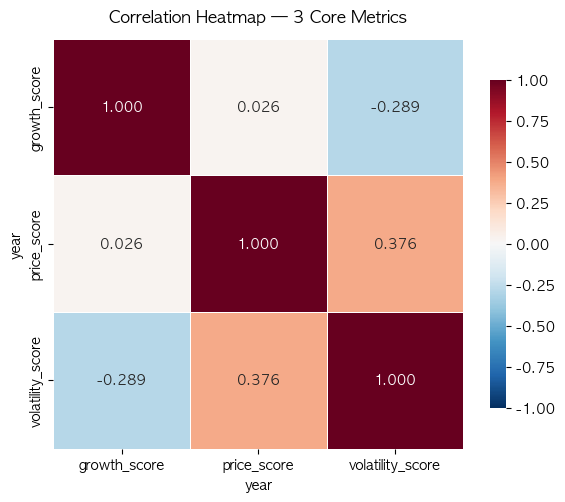

Max absolute correlation: 0.376
→ The three metrics are sufficiently independent. Z-score combination is valid.


In [40]:
# EDA: Metric Independence Check
# [Decision Rationale] If two metrics correlate strongly (|r| > 0.8),
# they carry nearly identical information → summing them double-counts.
# → Check independence before combining.

corr_df = district_scores[["growth_score", "price_score", "volatility_score"]].corr().round(3)
print("Correlation matrix (3 core metrics):")
print(corr_df.to_string())
print()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_df, annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, square=True, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Heatmap — 3 Core Metrics",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Auto-interpretation
max_corr = corr_df.abs().where(~np.eye(len(corr_df), dtype=bool)).max().max()
print(f"Max absolute correlation: {max_corr:.3f}")
if max_corr < 0.5:
    print("→ The three metrics are sufficiently independent. Z-score combination is valid.")
elif max_corr < 0.8:
    print("→ Moderate correlation detected. Interpret results with caution.")
else:
    print("→ High correlation detected. Two metrics may carry similar information.")

In [41]:
# Compute Weighted Investment Scores by Profile
# [Weight Design Rationale]
# Conservative: prioritizes stability (volatility weight = 1.5 — highest)
#               → Prefers districts with low price fluctuation
# Balanced:     equal weights (1.0 each)
#               → Considers all three metrics equally
# Aggressive:   prioritizes growth (growth weight = 1.5 — highest)
#               → Prefers high-growth districts for maximum return potential
#
# ※ All profiles sum to 3.0 → scores are on the same scale (fair comparison)

# Conservative: growth(0.5) + price(1.0) + volatility(1.5)
district_scores["conservative_score"] = (
    0.5 * district_scores["growth_score"] +
    1.0 * district_scores["price_score"] +
    1.5 * district_scores["volatility_score"]
)

# Balanced: growth(1.0) + price(1.0) + volatility(1.0)
district_scores["balanced_score"] = (
    1.0 * district_scores["growth_score"] +
    1.0 * district_scores["price_score"] +
    1.0 * district_scores["volatility_score"]
)

# Aggressive: growth(1.5) + price(1.0) + volatility(0.5)
district_scores["aggressive_score"] = (
    1.5 * district_scores["growth_score"] +
    1.0 * district_scores["price_score"] +
    0.5 * district_scores["volatility_score"]
)

conservative_rank = district_scores.sort_values("conservative_score", ascending=False).reset_index(drop=True)
balanced_rank     = district_scores.sort_values("balanced_score",     ascending=False).reset_index(drop=True)
aggressive_rank   = district_scores.sort_values("aggressive_score",   ascending=False).reset_index(drop=True)

In [42]:
# District Ranking Results 
print("=== Conservative TOP3 ===")
print(conservative_rank[["district","conservative_score","growth_score","price_score","volatility_score"]].head(3).to_string(index=False))

print("\n=== Balanced TOP3 ===")
print(balanced_rank[["district","balanced_score","growth_score","price_score","volatility_score"]].head(3).to_string(index=False))

print("\n=== Aggressive TOP3 ===")
print(aggressive_rank[["district","aggressive_score","growth_score","price_score","volatility_score"]].head(3).to_string(index=False))

=== Conservative TOP3 ===
district  conservative_score  growth_score  price_score  volatility_score
     중랑구             3.01900        1.0419       0.8662            1.0879
     도봉구             2.49390       -1.0852       1.6241            0.9416
     관악구             2.48295       -0.8162       0.9571            1.2893

=== Balanced TOP3 ===
district  balanced_score  growth_score  price_score  volatility_score
     중랑구          2.9960        1.0419       0.8662            1.0879
     금천구          2.7901        1.2435       0.9270            0.6196
     은평구          1.8658        0.1905       0.9052            0.7701

=== Aggressive TOP3 ===
district  aggressive_score  growth_score  price_score  volatility_score
     금천구           3.10205        1.2435       0.9270            0.6196
     중랑구           2.97300        1.0419       0.8662            1.0879
    서대문구           1.77970        1.0217      -0.0049            0.5041


## Sensitivity Analysis — Weight Robustness Check

In [43]:
# Sensitivity Analysis 
# [Decision Rationale] Validate that our weight choices don't arbitrarily
# determine the results. If TOP3 remains stable across different weight
# combinations → results are robust and trustworthy.
# If TOP3 changes significantly → investors should customize weights.

weight_scenarios = {
    "Conservative Base (0.5/1.0/1.5)": (0.5, 1.0, 1.5),
    "Conservative Alt1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "Conservative Alt2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
    "Balanced Base (1.0/1.0/1.0)":     (1.0, 1.0, 1.0),
    "Aggressive Base (1.5/1.0/0.5)":   (1.5, 1.0, 0.5),
    "Aggressive Alt1 (1.7/1.0/0.3)":   (1.7, 1.0, 0.3),
    "Aggressive Alt2 (1.3/1.0/0.7)":   (1.3, 1.0, 0.7),
}

print("Weight Scenario → TOP3 District Comparison")
print("-" * 65)

results = {}
for scenario_name, (wg, wp, wv) in weight_scenarios.items():
    temp = district_scores.copy()
    temp["scenario_score"] = (
        wg * temp["growth_score"] +
        wp * temp["price_score"] +
        wv * temp["volatility_score"]
    )
    top3 = temp.sort_values("scenario_score", ascending=False).head(3)["district"].tolist()
    results[scenario_name] = top3
    print(f"{scenario_name}")
    print(f"  TOP3: {top3[0]}, {top3[1]}, {top3[2]}")
    print()

# District appearance frequency across all scenarios
all_top3 = [d for top in results.values() for d in top]
freq = Counter(all_top3).most_common(10)
print("District frequency in TOP3 across all scenarios:")
for district, cnt in freq:
    bar = "█" * cnt
    print(f"  {district:8s}: {bar} ({cnt}/{len(weight_scenarios)} scenarios)")

Weight Scenario → TOP3 District Comparison
-----------------------------------------------------------------
Conservative Base (0.5/1.0/1.5)
  TOP3: 중랑구, 도봉구, 관악구

Conservative Alt1 (0.3/1.0/1.7)
  TOP3: 중랑구, 관악구, 도봉구

Conservative Alt2 (0.7/1.0/1.3)
  TOP3: 중랑구, 금천구, 강북구

Balanced Base (1.0/1.0/1.0)
  TOP3: 중랑구, 금천구, 은평구

Aggressive Base (1.5/1.0/0.5)
  TOP3: 금천구, 중랑구, 서대문구

Aggressive Alt1 (1.7/1.0/0.3)
  TOP3: 금천구, 중랑구, 성북구

Aggressive Alt2 (1.3/1.0/0.7)
  TOP3: 중랑구, 금천구, 은평구

District frequency in TOP3 across all scenarios:
  중랑구     : ███████ (7/7 scenarios)
  금천구     : █████ (5/7 scenarios)
  도봉구     : ██ (2/7 scenarios)
  관악구     : ██ (2/7 scenarios)
  은평구     : ██ (2/7 scenarios)
  강북구     : █ (1/7 scenarios)
  서대문구    : █ (1/7 scenarios)
  성북구     : █ (1/7 scenarios)


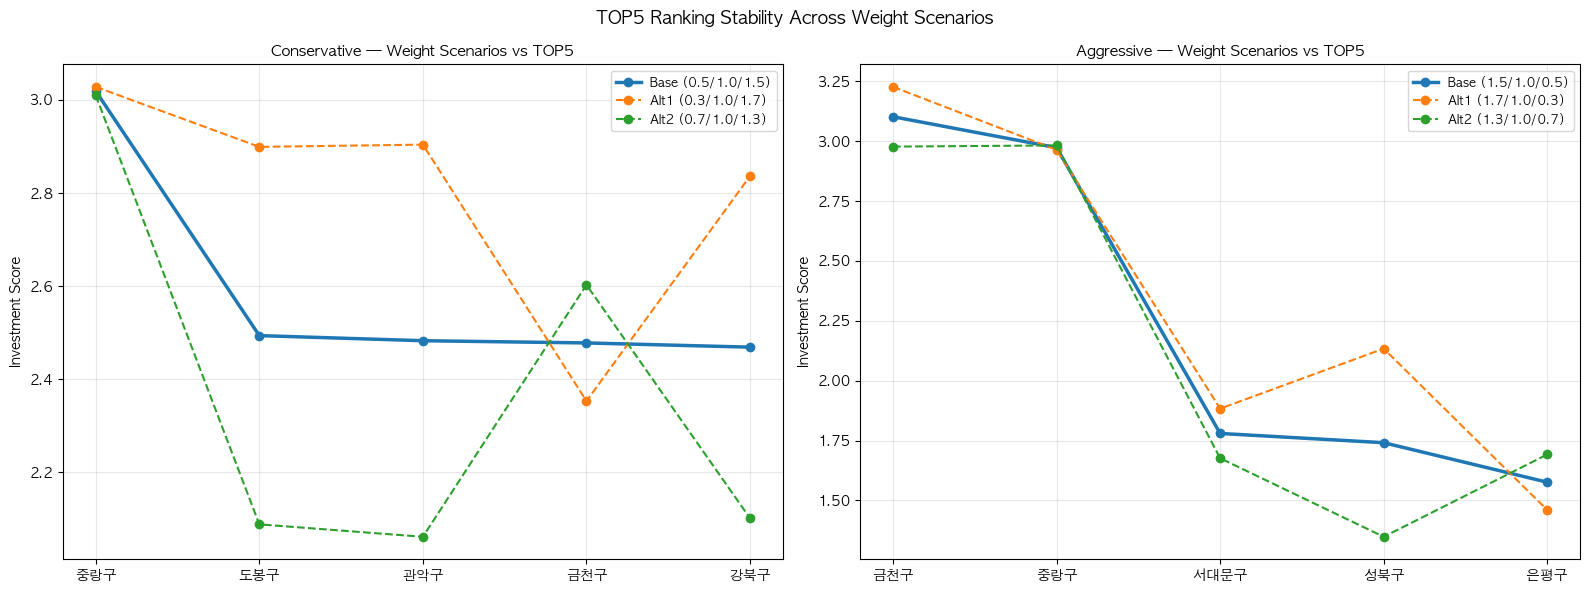

→ Similar line shapes = TOP3 ranking is robust across weight variations.


In [44]:
# Sensitivity Analysis Visualization
safe_scenarios = {
    "Base (0.5/1.0/1.5)": (0.5, 1.0, 1.5),
    "Alt1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "Alt2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
}
aggr_scenarios = {
    "Base (1.5/1.0/0.5)": (1.5, 1.0, 0.5),
    "Alt1 (1.7/1.0/0.3)": (1.7, 1.0, 0.3),
    "Alt2 (1.3/1.0/0.7)": (1.3, 1.0, 0.7),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("TOP5 Ranking Stability Across Weight Scenarios",
             fontsize=13, fontweight="bold")

colors_line = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ax, scenarios, title in [
    (axes[0], safe_scenarios, "Conservative — Weight Scenarios vs TOP5"),
    (axes[1], aggr_scenarios, "Aggressive — Weight Scenarios vs TOP5"),
]:
    base_w = list(scenarios.values())[0]
    temp_base = district_scores.copy()
    temp_base["score"] = (
        base_w[0] * temp_base["growth_score"] +
        base_w[1] * temp_base["price_score"] +
        base_w[2] * temp_base["volatility_score"]
    )
    top5_districts = temp_base.sort_values("score", ascending=False).head(5)["district"].tolist()

    x = range(len(top5_districts))
    for idx, (sname, (wg, wp, wv)) in enumerate(scenarios.items()):
        temp = district_scores.copy()
        temp["score"] = wg * temp["growth_score"] + wp * temp["price_score"] + wv * temp["volatility_score"]
        scores = temp[temp["district"].isin(top5_districts)].set_index("district").loc[top5_districts]["score"]
        lw = 2.5 if idx == 0 else 1.5
        ls = "-" if idx == 0 else "--"
        ax.plot(x, scores.values, marker="o", linewidth=lw, linestyle=ls,
                color=colors_line[idx], label=sname)

    ax.set_xticks(list(x))
    ax.set_xticklabels(top5_districts, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Investment Score")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Similar line shapes = TOP3 ranking is robust across weight variations.")

## Visualization — Investment Attractiveness by District

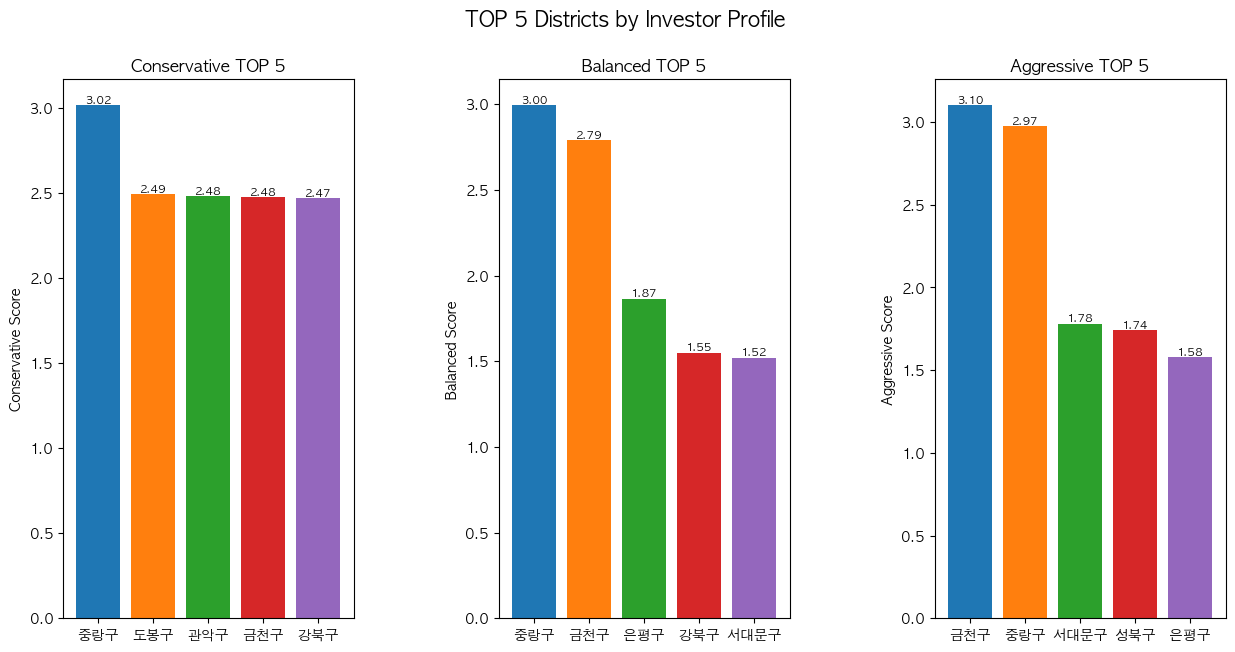

In [45]:
# TOP5 by Investor Profile
cons_top5 = conservative_rank.head(5)[["district", "conservative_score"]]
bal_top5  = balanced_rank.head(5)[["district", "balanced_score"]]
aggr_top5 = aggressive_rank.head(5)[["district", "aggressive_score"]]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle("TOP 5 Districts by Investor Profile", fontsize=15)
fig.subplots_adjust(wspace=0.5)

for ax, df_top, score_col, title, ylabel in [
    (axes[0], cons_top5, "conservative_score", "Conservative TOP 5", "Conservative Score"),
    (axes[1], bal_top5,  "balanced_score",     "Balanced TOP 5",     "Balanced Score"),
    (axes[2], aggr_top5, "aggressive_score",   "Aggressive TOP 5",   "Aggressive Score"),
]:
    ax.bar(range(len(df_top)), df_top[score_col], color=colors[:len(df_top)])
    ax.set_xticks(range(len(df_top)))
    ax.set_xticklabels(df_top["district"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(df_top[score_col]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.show()

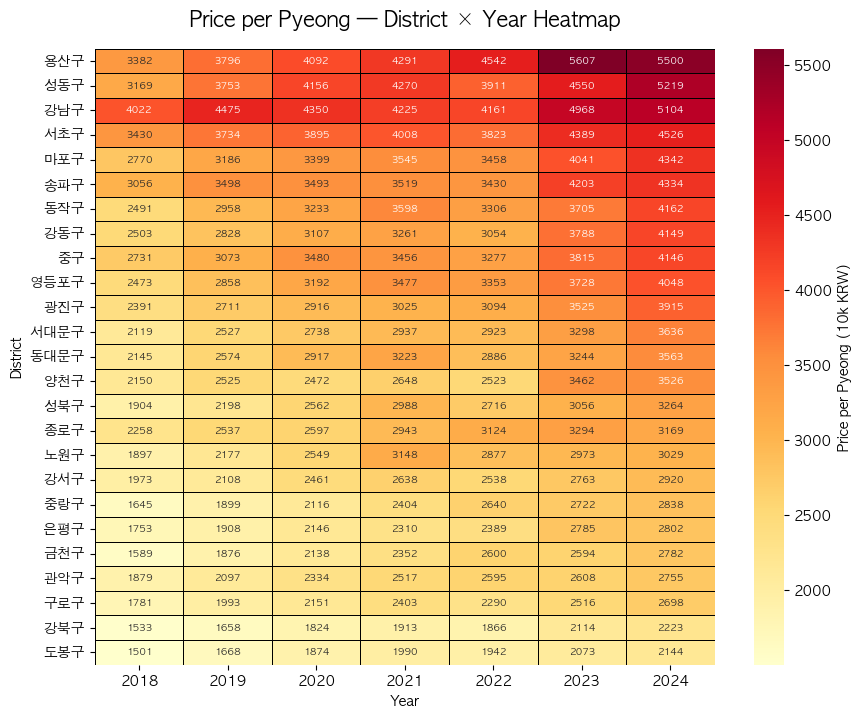

In [46]:
# Heatmap: Price per Pyeong — District × Year
latest_year = max(years)
df_heat = price_pivot.copy()
df_heat = df_heat.sort_values(latest_year, ascending=False)
df_heat = df_heat.set_index("district")[years]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_heat, cmap="YlOrRd", linewidths=0.5, linecolor="black",
    cbar_kws={"label": "Price per Pyeong (10k KRW)"},
    annot=True, annot_kws={"fontsize": 7}, fmt=".0f"
)
plt.title("Price per Pyeong — District × Year Heatmap",
          pad=16, fontsize=15, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("District")
plt.show()

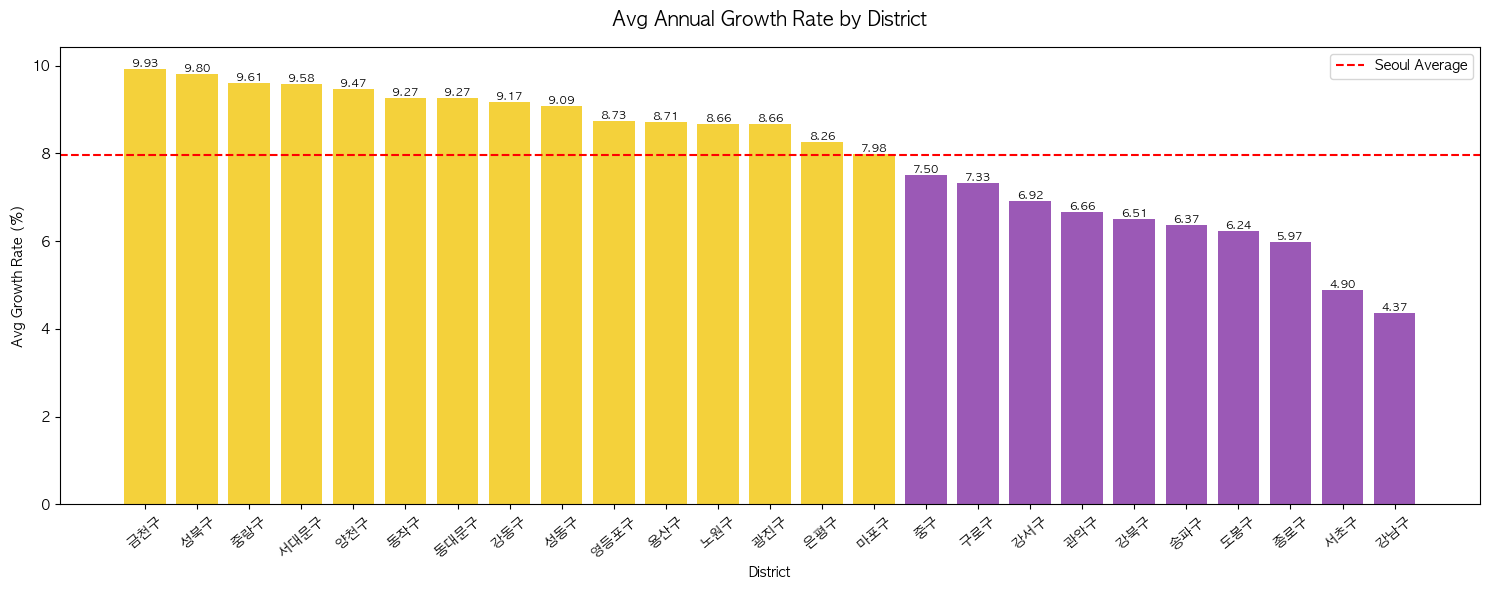

In [47]:
# Bar Chart: Avg Growth Rate by District
df_growth = district_metrics[["district", "avg_growth_rate"]].copy()
df_growth = df_growth.sort_values("avg_growth_rate", ascending=False).reset_index(drop=True)
seoul_avg_growth = df_growth["avg_growth_rate"].mean()

colors = ["#F4D13B" if g >= seoul_avg_growth else "#9b59b6" for g in df_growth["avg_growth_rate"]]

plt.figure(figsize=(15, 6))
plt.bar(range(len(df_growth)), df_growth["avg_growth_rate"], color=colors)
plt.xticks(range(len(df_growth)), df_growth["district"], rotation=40)
plt.title("Avg Annual Growth Rate by District", pad=15, fontsize=14, fontweight="bold")
plt.xlabel("District")
plt.ylabel("Avg Growth Rate (%)")
plt.axhline(y=seoul_avg_growth, color="red", linestyle="--",
            linewidth=1.5, label="Seoul Average")
plt.legend(loc="upper right")
plt.tight_layout()
for i, v in enumerate(df_growth["avg_growth_rate"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()

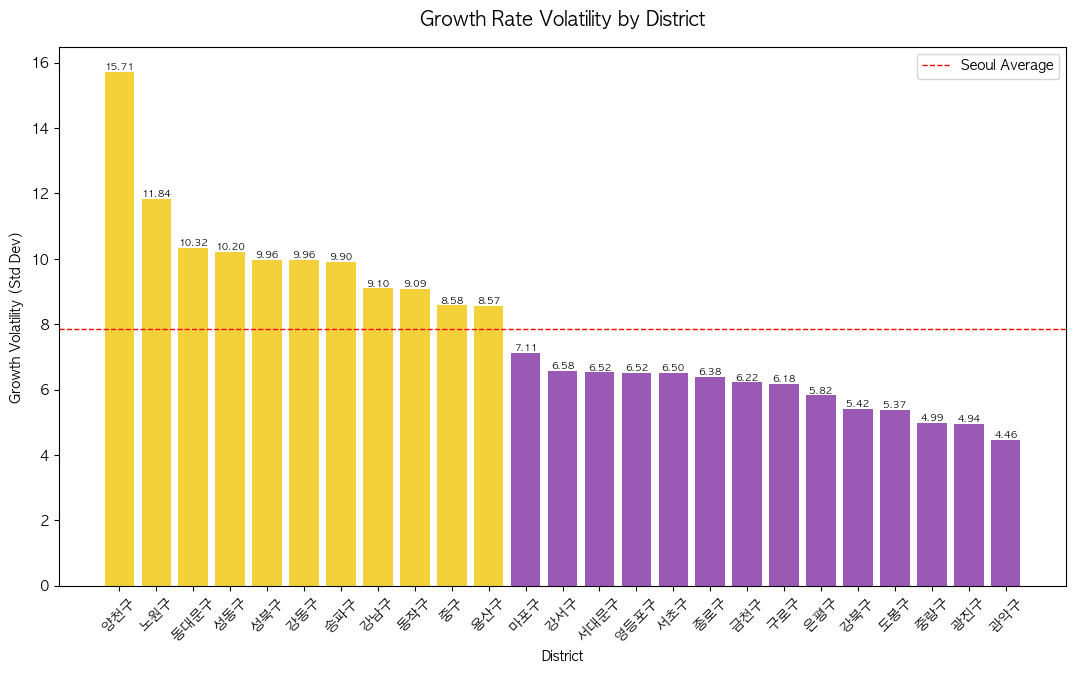

In [48]:
# Bar Chart: Growth Volatility by District
df_vol = district_metrics[["district", "growth_volatility"]].copy()
df_vol = df_vol.sort_values("growth_volatility", ascending=False).reset_index(drop=True)
seoul_avg_vol = df_vol["growth_volatility"].mean()

colors = ["#9b59b6" if v <= seoul_avg_vol else "#F4D13B" for v in df_vol["growth_volatility"]]

plt.figure(figsize=(13, 7))
plt.bar(range(len(df_vol)), df_vol["growth_volatility"], color=colors)
plt.xticks(range(len(df_vol)), df_vol["district"], rotation=45)
plt.title("Growth Rate Volatility by District",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("District")
plt.ylabel("Growth Volatility (Std Dev)")
plt.axhline(seoul_avg_vol, color="red", linestyle="--",
            linewidth=1, label="Seoul Average")
plt.legend(loc="upper right")
for i, v in enumerate(df_vol["growth_volatility"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
plt.show()

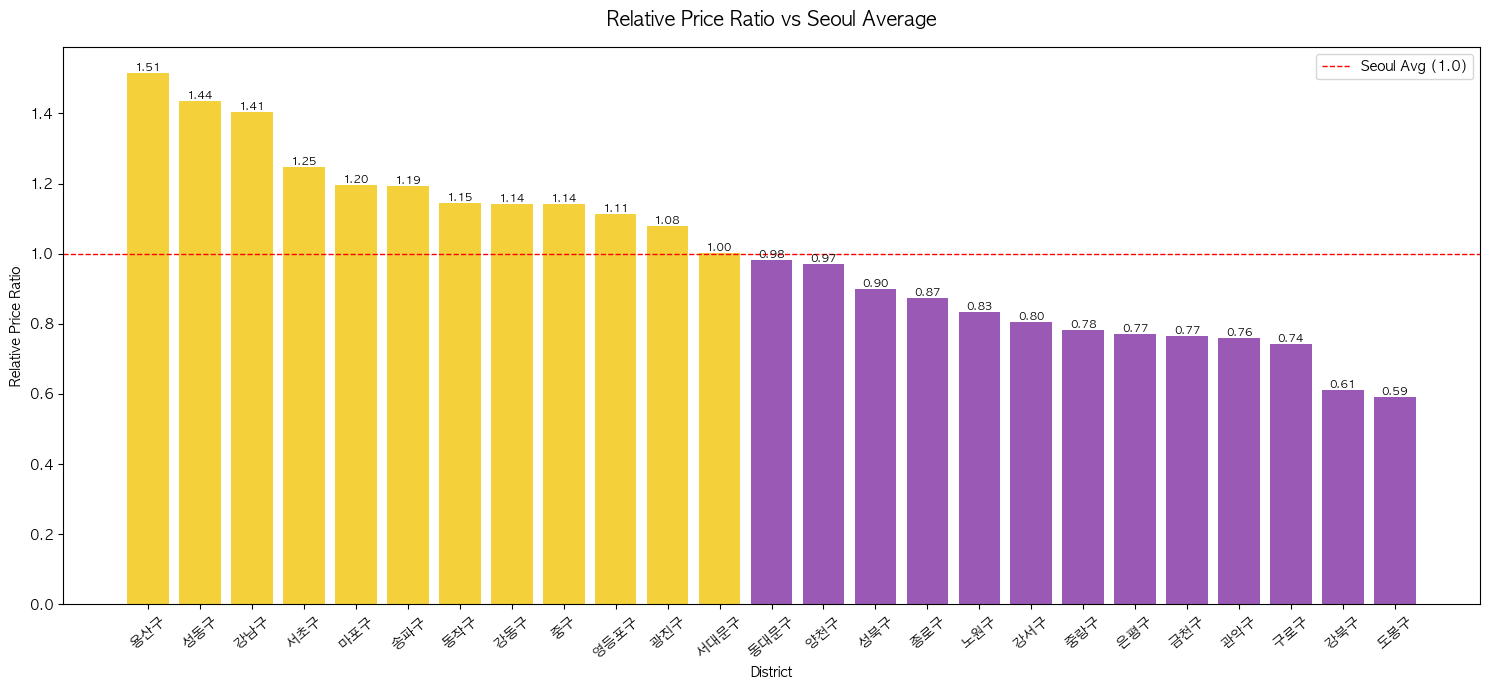

In [49]:
# Bar Chart: Relative Price Ratio by District
df_price_ratio = district_metrics[["district", "relative_price_ratio"]].copy()
df_price_ratio = df_price_ratio.sort_values("relative_price_ratio", ascending=False).reset_index(drop=True)

colors = ["#F4D13B" if ratio > 1 else "#9b59b6" for ratio in df_price_ratio["relative_price_ratio"]]

plt.figure(figsize=(15, 7))
plt.bar(range(len(df_price_ratio)), df_price_ratio["relative_price_ratio"], color=colors)
plt.xticks(range(len(df_price_ratio)), df_price_ratio["district"], rotation=40)
plt.title("Relative Price Ratio vs Seoul Average",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("District")
plt.ylabel("Relative Price Ratio")
plt.axhline(1, color="red", linestyle="--", linewidth=1, label="Seoul Avg (1.0)")
plt.legend(loc="upper right")
plt.tight_layout()
for i, v in enumerate(df_price_ratio["relative_price_ratio"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()

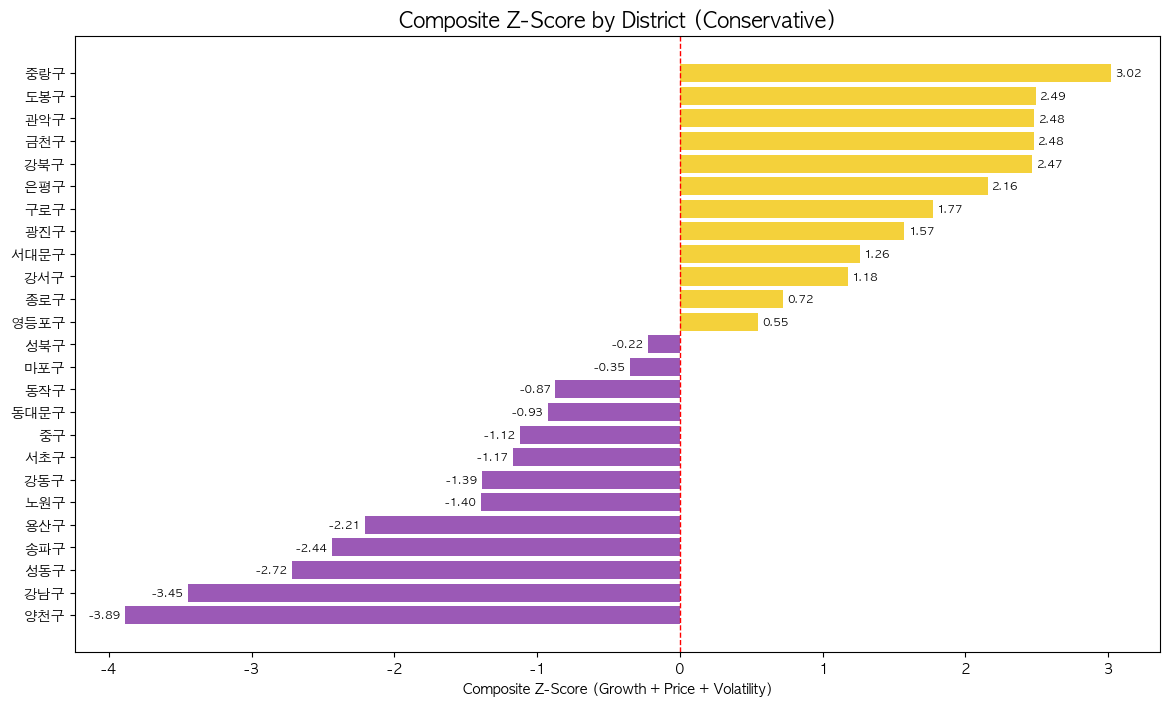

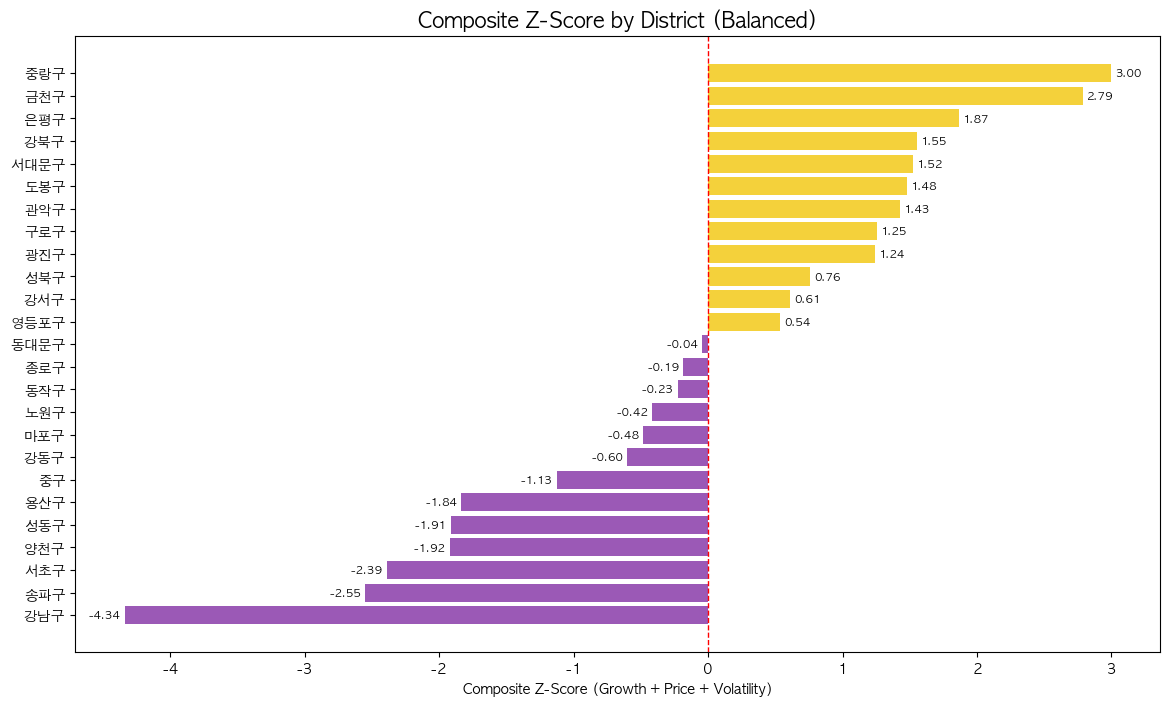

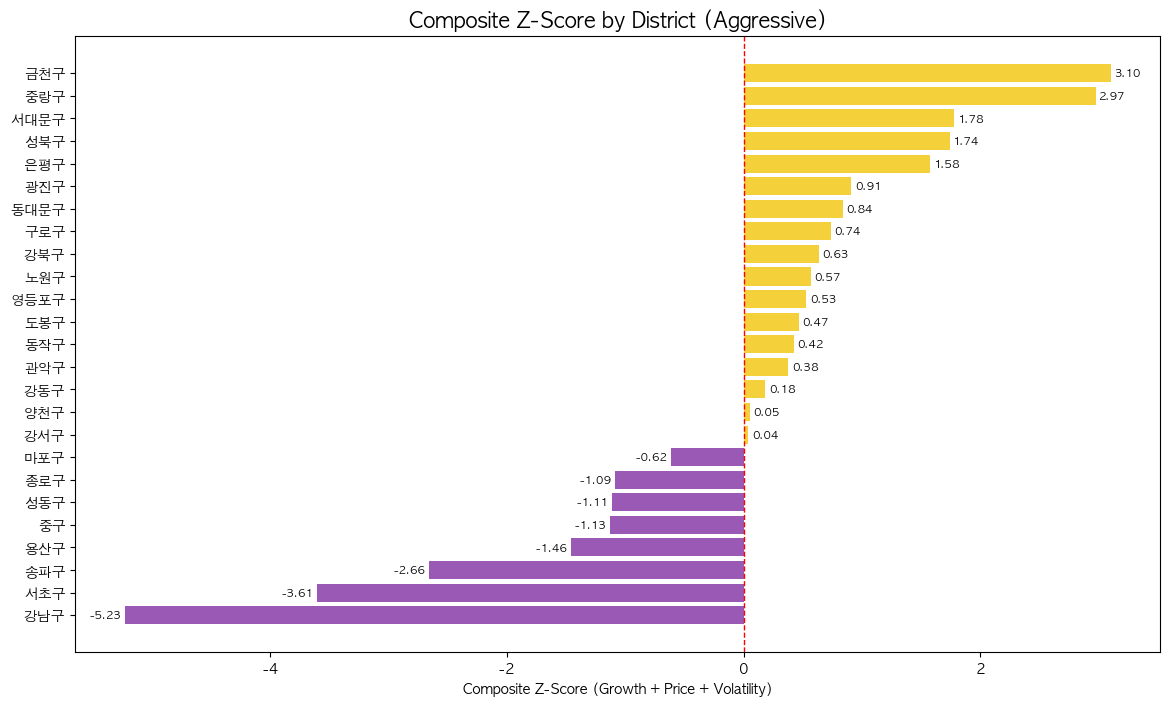

In [50]:
# Horizontal Bar: Z-Score Composite by Profile
for score_col, title in [
    ("conservative_score", "Conservative"),
    ("balanced_score",     "Balanced"),
    ("aggressive_score",   "Aggressive"),
]:
    df_plot = district_scores[["district", score_col]].sort_values(score_col, ascending=True).reset_index(drop=True)
    colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_plot[score_col]]

    plt.figure(figsize=(14, 8))
    plt.barh(range(len(df_plot)), df_plot[score_col], color=colors)
    plt.yticks(range(len(df_plot)), df_plot["district"])
    plt.title(f"Composite Z-Score by District ({title})",
              fontsize=15, fontweight="bold")
    plt.xlabel("Composite Z-Score (Growth + Price + Volatility)")
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    for i, v in enumerate(df_plot[score_col]):
        x_pos = v + 0.03 if v >= 0 else v - 0.03
        ha = "left" if v >= 0 else "right"
        plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
    plt.show()

## Building-Type Analysis within TOP3 Districts

In [51]:
# Conservative: Building Type Analysis
top3_cons_list = conservative_rank.head(3)["district"].tolist()
print("Conservative TOP3 districts:", top3_cons_list)

df_cons_top = df_all[df_all["district"].isin(top3_cons_list)].copy()
print("Data size:", df_cons_top.shape)
print("Building type distribution:")
print(df_cons_top["building_type"].value_counts())

cons_price_pivot = df_cons_top.pivot_table(
    index=["district", "building_type"], columns="year",
    values="price_per_pyeong", aggfunc="mean"
).reset_index()
print(cons_price_pivot)

Conservative TOP3 districts: ['중랑구', '도봉구', '관악구']
Data size: (89803, 25)
Building type distribution:
building_type
아파트      40406
연립다세대    37060
단독다가구     7274
오피스텔      5063
Name: count, dtype: int64
year district building_type         2018         2019         2020  \
0         관악구         단독다가구  1663.655908  1786.858786  1986.211078   
1         관악구           아파트  2108.614987  2484.796027  2837.816644   
2         관악구         연립다세대  1646.589356  1757.634865  1869.676455   
3         관악구          오피스텔  2013.970979  2133.798207  2167.712075   
4         도봉구         단독다가구  1158.207780  1382.853036  1376.297485   
5         도봉구           아파트  1661.983712  1925.305375  2205.173609   
6         도봉구         연립다세대  1135.527567  1239.302127  1298.560417   
7         도봉구          오피스텔  1412.726222  1625.181199  1699.366615   
8         중랑구         단독다가구  1341.853572  1470.318130  1493.815832   
9         중랑구           아파트  1776.742318  2167.951853  2471.336904   
10        중랑구         연립다세대 

In [53]:
# Conservative: YoY Growth & Z-Score by District × Building Type
cons_growth = cons_price_pivot.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    col_name = f"growth_{pre_y}_{cur_y}"
    cons_growth[col_name] = (
        (cons_growth[cur_y] - cons_growth[pre_y]) / cons_growth[pre_y] * 100
    )

g_cols = [c for c in cons_growth.columns if str(c).startswith("growth_")]
cons_growth["avg_growth_rate"]  = cons_growth[g_cols].mean(axis=1)
cons_growth["growth_volatility"] = cons_growth[g_cols].std(axis=1)
cons_growth["current_price_per_pyeong"] = cons_growth[years[-1]]

# Z-score normalization
cs = cons_growth.copy()
for col, z_col, flip in [
    ("avg_growth_rate",           "growth_z_c",     False),
    ("current_price_per_pyeong",  "price_z_c",      True),
    ("growth_volatility",         "volatility_z_c", True),
]:
    m, s = cs[col].mean(), cs[col].std()
    raw_z = (cs[col] - m) / s
    cs[z_col] = (-raw_z if flip else raw_z).round(4)

cs["conservative_bldg_score"] = (
    0.5 * cs["growth_z_c"] + 1.0 * cs["price_z_c"] + 1.5 * cs["volatility_z_c"]
)
cons_bldg_rank = cs.sort_values("conservative_bldg_score", ascending=False).reset_index(drop=True)
print(cons_bldg_rank[["district","building_type","conservative_bldg_score",
                       "avg_growth_rate","growth_volatility","current_price_per_pyeong"]].to_string(index=False))

district building_type  conservative_bldg_score  avg_growth_rate  growth_volatility  current_price_per_pyeong
     도봉구         연립다세대                  2.15550         5.610283           8.560731               1548.462954
     관악구         단독다가구                  2.05310         3.580054           5.789078               2038.440905
     중랑구         연립다세대                  1.50765         9.871810           6.981266               2736.525227
     관악구         연립다세대                  1.40380         4.697276           7.880702               2137.849486
     중랑구         단독다가구                  1.03390         1.071897          10.976834               1387.742190
     도봉구         단독다가구                  0.52335         2.692204          13.700384               1298.623517
     관악구          오피스텔                 -0.49040         3.623544          12.268139               2404.437669
     중랑구           아파트                 -1.07850        10.046343          13.982120               3030.369296
     도봉구  

In [55]:
# Balanced: Building Type Analysis
top3_bal_list = balanced_rank.head(3)["district"].tolist()
df_bal_top = df_all[df_all["district"].isin(top3_bal_list)].copy()
bal_price_pivot = df_bal_top.pivot_table(
    index=["district","building_type"], columns="year",
    values="price_per_pyeong", aggfunc="mean"
).reset_index()

bal_growth = bal_price_pivot.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    bal_growth[f"growth_{pre_y}_{cur_y}"] = (
        (bal_growth[cur_y] - bal_growth[pre_y]) / bal_growth[pre_y] * 100
    )

g_cols_b = [c for c in bal_growth.columns if str(c).startswith("growth_")]
bal_growth["avg_growth_rate"]           = bal_growth[g_cols_b].mean(axis=1)
bal_growth["growth_volatility"]         = bal_growth[g_cols_b].std(axis=1)
bal_growth["current_price_per_pyeong"]  = bal_growth[years[-1]]

bs = bal_growth.copy()
for col, z_col, flip in [
    ("avg_growth_rate","growth_z_b",False),
    ("current_price_per_pyeong","price_z_b",True),
    ("growth_volatility","volatility_z_b",True),
]:
    m, s = bs[col].mean(), bs[col].std()
    raw_z = (bs[col] - m) / s
    bs[z_col] = (-raw_z if flip else raw_z).round(4)

bs["balanced_bldg_score"] = bs["growth_z_b"] + bs["price_z_b"] + bs["volatility_z_b"]
bal_bldg_rank = bs.sort_values("balanced_bldg_score", ascending=False).reset_index(drop=True)
print(bal_bldg_rank[["district","building_type","balanced_bldg_score",
                      "avg_growth_rate","growth_volatility","current_price_per_pyeong"]].to_string(index=False))

district building_type  balanced_bldg_score  avg_growth_rate  growth_volatility  current_price_per_pyeong
     은평구         연립다세대               1.5220         5.849286           5.398575               2137.855680
     금천구         연립다세대               1.2680         6.594257           6.538460               2246.192456
     중랑구         연립다세대               1.1964         9.871810           6.981266               2736.525227
     금천구         단독다가구               0.7959         2.591057           9.608156               1447.582388
     은평구         단독다가구               0.2398         2.496255           8.526395               2007.290737
     중랑구         단독다가구               0.2272         1.071897          10.976834               1387.742190
     금천구          오피스텔              -0.4919        11.915168          13.296936               3211.138327
     은평구           아파트              -0.6583        10.353970           9.804060               3663.598993
     금천구           아파트              -0.7748   

In [57]:
# Aggressive: Building Type Analysis
top3_aggr_list = aggressive_rank.head(3)["district"].tolist()
df_aggr_top = df_all[df_all["district"].isin(top3_aggr_list)].copy()
aggr_price_pivot = df_aggr_top.pivot_table(
    index=["district","building_type"], columns="year",
    values="price_per_pyeong", aggfunc="mean"
).reset_index()

aggr_growth = aggr_price_pivot.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    aggr_growth[f"growth_{pre_y}_{cur_y}"] = (
        (aggr_growth[cur_y] - aggr_growth[pre_y]) / aggr_growth[pre_y] * 100
    )

g_cols_a = [c for c in aggr_growth.columns if str(c).startswith("growth_")]
aggr_growth["avg_growth_rate"]          = aggr_growth[g_cols_a].mean(axis=1)
aggr_growth["growth_volatility"]        = aggr_growth[g_cols_a].std(axis=1)
aggr_growth["current_price_per_pyeong"] = aggr_growth[years[-1]]

ag = aggr_growth.copy()
for col, z_col, flip in [
    ("avg_growth_rate","growth_z_a",False),
    ("current_price_per_pyeong","price_z_a",True),
    ("growth_volatility","volatility_z_a",True),
]:
    m, s = ag[col].mean(), ag[col].std()
    raw_z = (ag[col] - m) / s
    ag[z_col] = (-raw_z if flip else raw_z).round(4)

ag["aggressive_bldg_score"] = (
    1.5 * ag["growth_z_a"] + 1.0 * ag["price_z_a"] + 0.5 * ag["volatility_z_a"]
)
aggr_bldg_rank = ag.sort_values("aggressive_bldg_score", ascending=False).reset_index(drop=True)
print(aggr_bldg_rank[["district","building_type","aggressive_bldg_score",
                       "avg_growth_rate","growth_volatility","current_price_per_pyeong"]].to_string(index=False))

district building_type  aggressive_bldg_score  avg_growth_rate  growth_volatility  current_price_per_pyeong
     중랑구         연립다세대                1.21120         9.871810           6.981266               2736.525227
     중랑구          오피스텔                0.82125        13.268676          20.782882               2836.604392
     금천구          오피스텔                0.71005        11.915168          13.296936               3211.138327
     금천구         연립다세대                0.53965         6.594257           6.538460               2246.192456
     금천구           아파트                0.38905        10.952737          14.847470               3005.038638
     중랑구           아파트                0.09640        10.046343          13.982120               3030.369296
    서대문구         연립다세대               -0.33540         5.244283           9.328888               2247.582886
    서대문구          오피스텔               -0.36525         8.603621           6.231014               3690.451667
    서대문구         단독다가구      

## Final Results

In [58]:
# Final Summary Table
# Maps directly to the PPT results slide (1:1 correspondence)

def get_top3_labels(rank_df, score_col):
    top = rank_df.head(3)
    return [f"{r['district']} ({r['building_type']})" for _, r in top.iterrows()]

summary_df = pd.DataFrame({
    "Investor Profile": ["Conservative", "Balanced", "Aggressive"],
    "Weights (Growth/Price/Vol)": [
        "0.5 / 1.0 / 1.5", "1.0 / 1.0 / 1.0", "1.5 / 1.0 / 0.5"
    ],
    "TOP 1": [
        get_top3_labels(cons_bldg_rank,  "conservative_bldg_score")[0],
        get_top3_labels(bal_bldg_rank,   "balanced_bldg_score")[0],
        get_top3_labels(aggr_bldg_rank,  "aggressive_bldg_score")[0],
    ],
    "TOP 2": [
        get_top3_labels(cons_bldg_rank,  "conservative_bldg_score")[1],
        get_top3_labels(bal_bldg_rank,   "balanced_bldg_score")[1],
        get_top3_labels(aggr_bldg_rank,  "aggressive_bldg_score")[1],
    ],
    "TOP 3": [
        get_top3_labels(cons_bldg_rank,  "conservative_bldg_score")[2],
        get_top3_labels(bal_bldg_rank,   "balanced_bldg_score")[2],
        get_top3_labels(aggr_bldg_rank,  "aggressive_bldg_score")[2],
    ],
})

print("=" * 70)
print(" Final Recommended Districts & Building Types by Investor Profile")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

 Final Recommended Districts & Building Types by Investor Profile
Investor Profile Weights (Growth/Price/Vol)       TOP 1       TOP 2       TOP 3
    Conservative            0.5 / 1.0 / 1.5 도봉구 (연립다세대) 관악구 (단독다가구) 중랑구 (연립다세대)
        Balanced            1.0 / 1.0 / 1.0 은평구 (연립다세대) 금천구 (연립다세대) 중랑구 (연립다세대)
      Aggressive            1.5 / 1.0 / 0.5 중랑구 (연립다세대)  중랑구 (오피스텔)  금천구 (오피스텔)


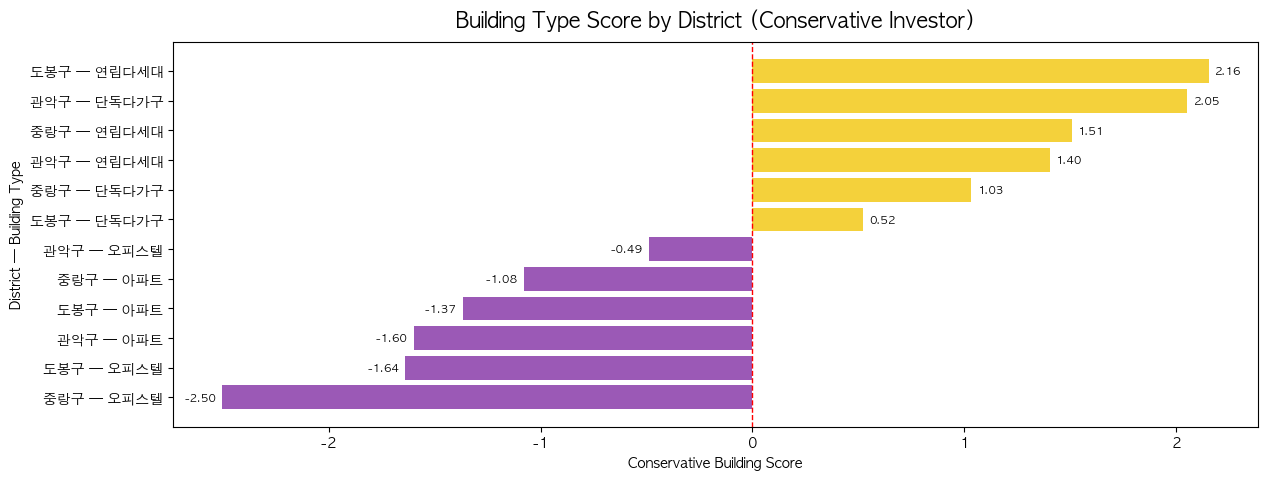

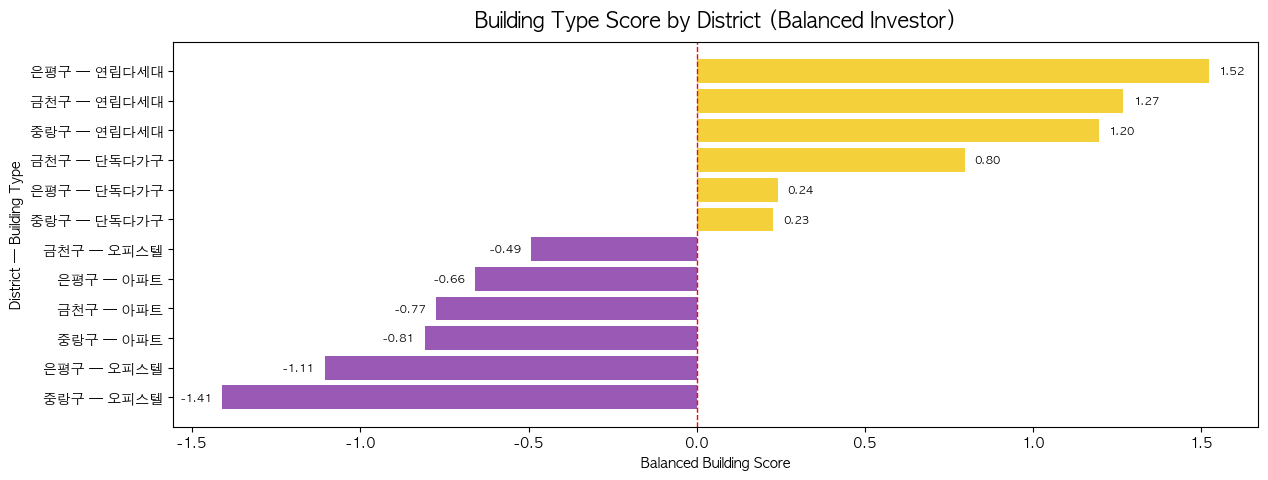

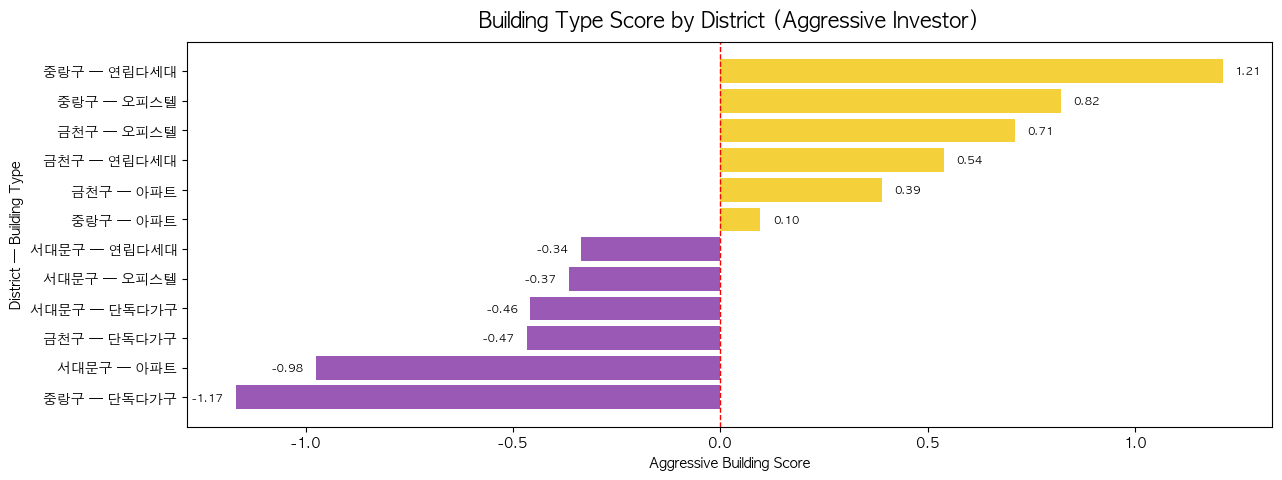

In [59]:
# Building Type Score Visualization (All 3 Profiles)
for bldg_rank, score_col, title in [
    (cons_bldg_rank,  "conservative_bldg_score", "Conservative"),
    (bal_bldg_rank,   "balanced_bldg_score",     "Balanced"),
    (aggr_bldg_rank,  "aggressive_bldg_score",   "Aggressive"),
]:
    df_r = bldg_rank.copy()
    df_r["label"] = df_r["district"] + " — " + df_r["building_type"]
    df_r = df_r.sort_values(score_col, ascending=True).reset_index(drop=True)
    colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_r[score_col]]

    plt.figure(figsize=(14, 5))
    plt.barh(df_r["label"], df_r[score_col], color=colors)
    plt.title(f"Building Type Score by District ({title} Investor)",
              fontsize=15, fontweight="bold", pad=10)
    plt.xlabel(f"{title} Building Score")
    plt.ylabel("District — Building Type")
    for i, v in enumerate(df_r[score_col]):
        x_pos = v + 0.03 if v >= 0 else v - 0.03
        ha = "left" if v >= 0 else "right"
        plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    plt.show()

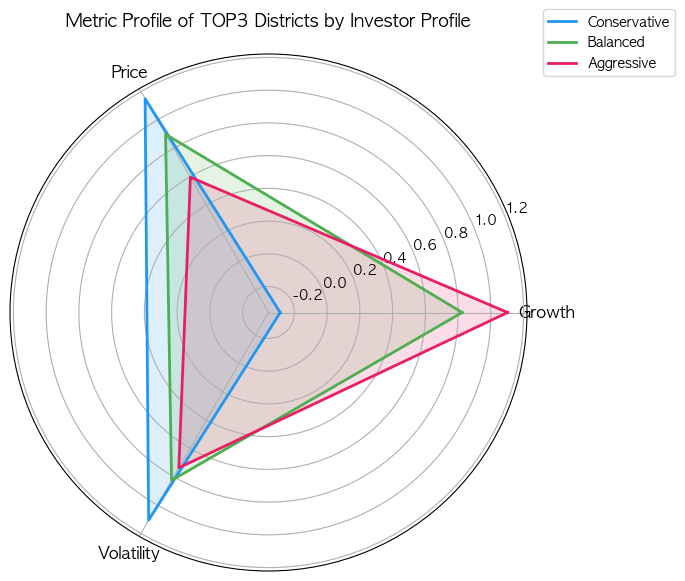

In [60]:
# Radar Chart: Metric Profile by Investor Profile
# Visualizes which metrics each profile prioritizes in their TOP3 districts
import numpy as np

def get_avg_scores(rank_df, n=3):
    top = rank_df.head(n)
    return {
        "Growth":     top["growth_score"].mean(),
        "Price":      top["price_score"].mean(),
        "Volatility": top["volatility_score"].mean(),
    }

metrics_cons   = get_avg_scores(conservative_rank)
metrics_bal    = get_avg_scores(balanced_rank)
metrics_aggr   = get_avg_scores(aggressive_rank)

categories = ["Growth", "Price", "Volatility"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for metrics, label, color in [
    (metrics_cons, "Conservative", "#2196F3"),
    (metrics_bal,  "Balanced",     "#4CAF50"),
    (metrics_aggr, "Aggressive",   "#E91E63"),
]:
    values = [metrics[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title("Metric Profile of TOP3 Districts by Investor Profile",
             pad=20, fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

## Conclusions & Key Insights

### Core Decision Rationale
- **Z-score normalization**: Metrics (growth %, price 10k KRW, volatility %) have different units and scales. Z-score standardizes all to mean=0, std=1 for fair aggregation.
- **Dual preprocessing**: Market overview (raw data) vs Investment analysis (IQR cleaned) — tailored to each analysis objective.
- **Weight design**: All profiles sum to 3.0 → scores on the same scale for cross-profile comparison.
- **Sensitivity analysis**: TOP3 results remain stable across ±0.2 weight variations, confirming result robustness.

### Analytical Strengths
- Data-driven investment decision framework — no reliance on intuition or experience
- 3-metric composite evaluation: growth + price + volatility (vs simple price ranking)
- Recommendations extend to district × building type combinations
- Includes metric independence check (correlation analysis) and result stability check (sensitivity analysis)

### Limitations & Future Improvements
- Incorporating macroeconomic variables (interest rates, jeonse-to-price ratio) would improve accuracy
- Adding regional development factors (transportation, redevelopment plans) would better capture future growth potential
- A/B testing or holdout validation could further verify model reliability
